# Package preparation and loading

here we import all the packages we need in this tutorial. If you have not installed them, please install them first. There are two ways to install them:

1. Use command `conda install package_name` in the Anaconda Prompt.

2. Open the Anaconda Navigator, click on the **Environments** tab, select the environment you choose, and search for the package in the search bar. Click on the package name to select it, and then click on the **Apply** button to install it.

*Note*: The package `sklearn` is not the full name. It is the abbreviation of `scikit-learn`, which is a popular machine learning library in Python.

Example: For the firth method:

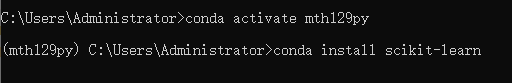

For the second method using graphical windows, click on the **Environments**:

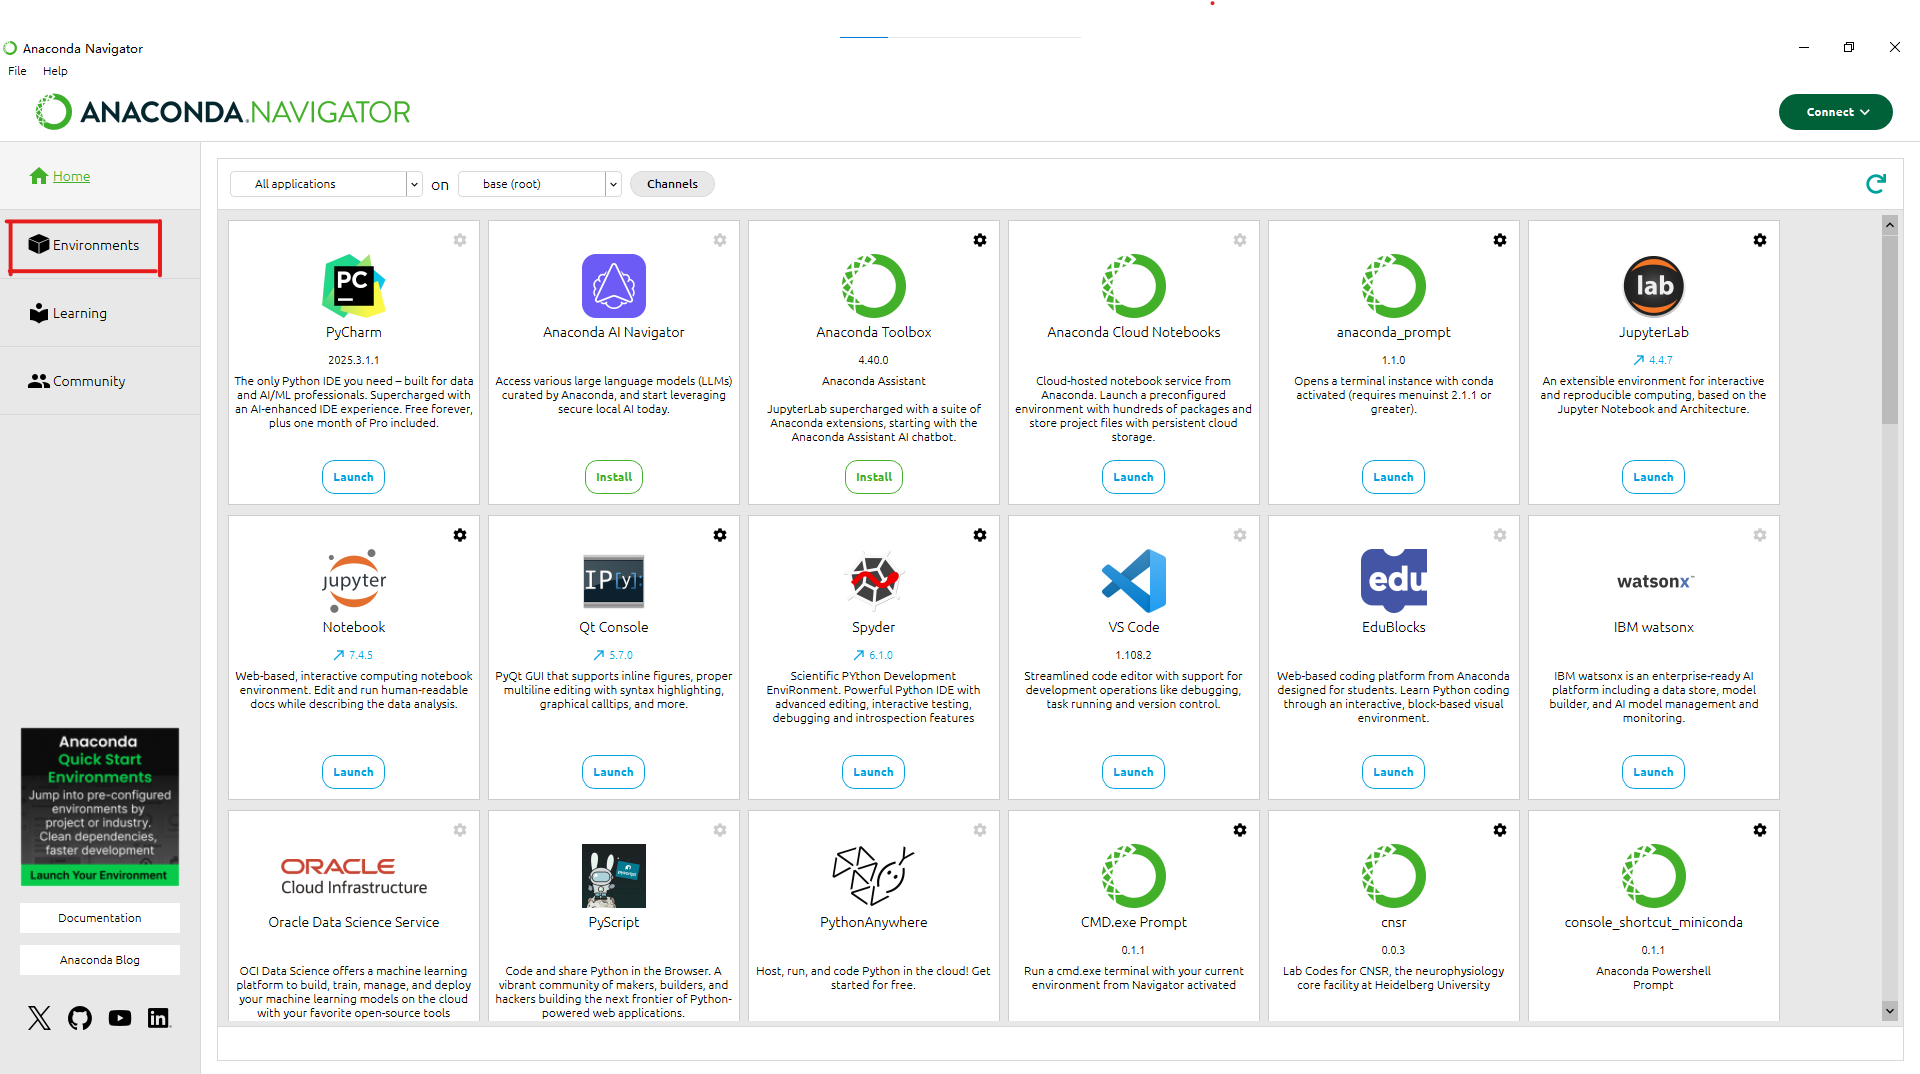

Choose your environment and choose "All" or "Not installed" to search for the package.

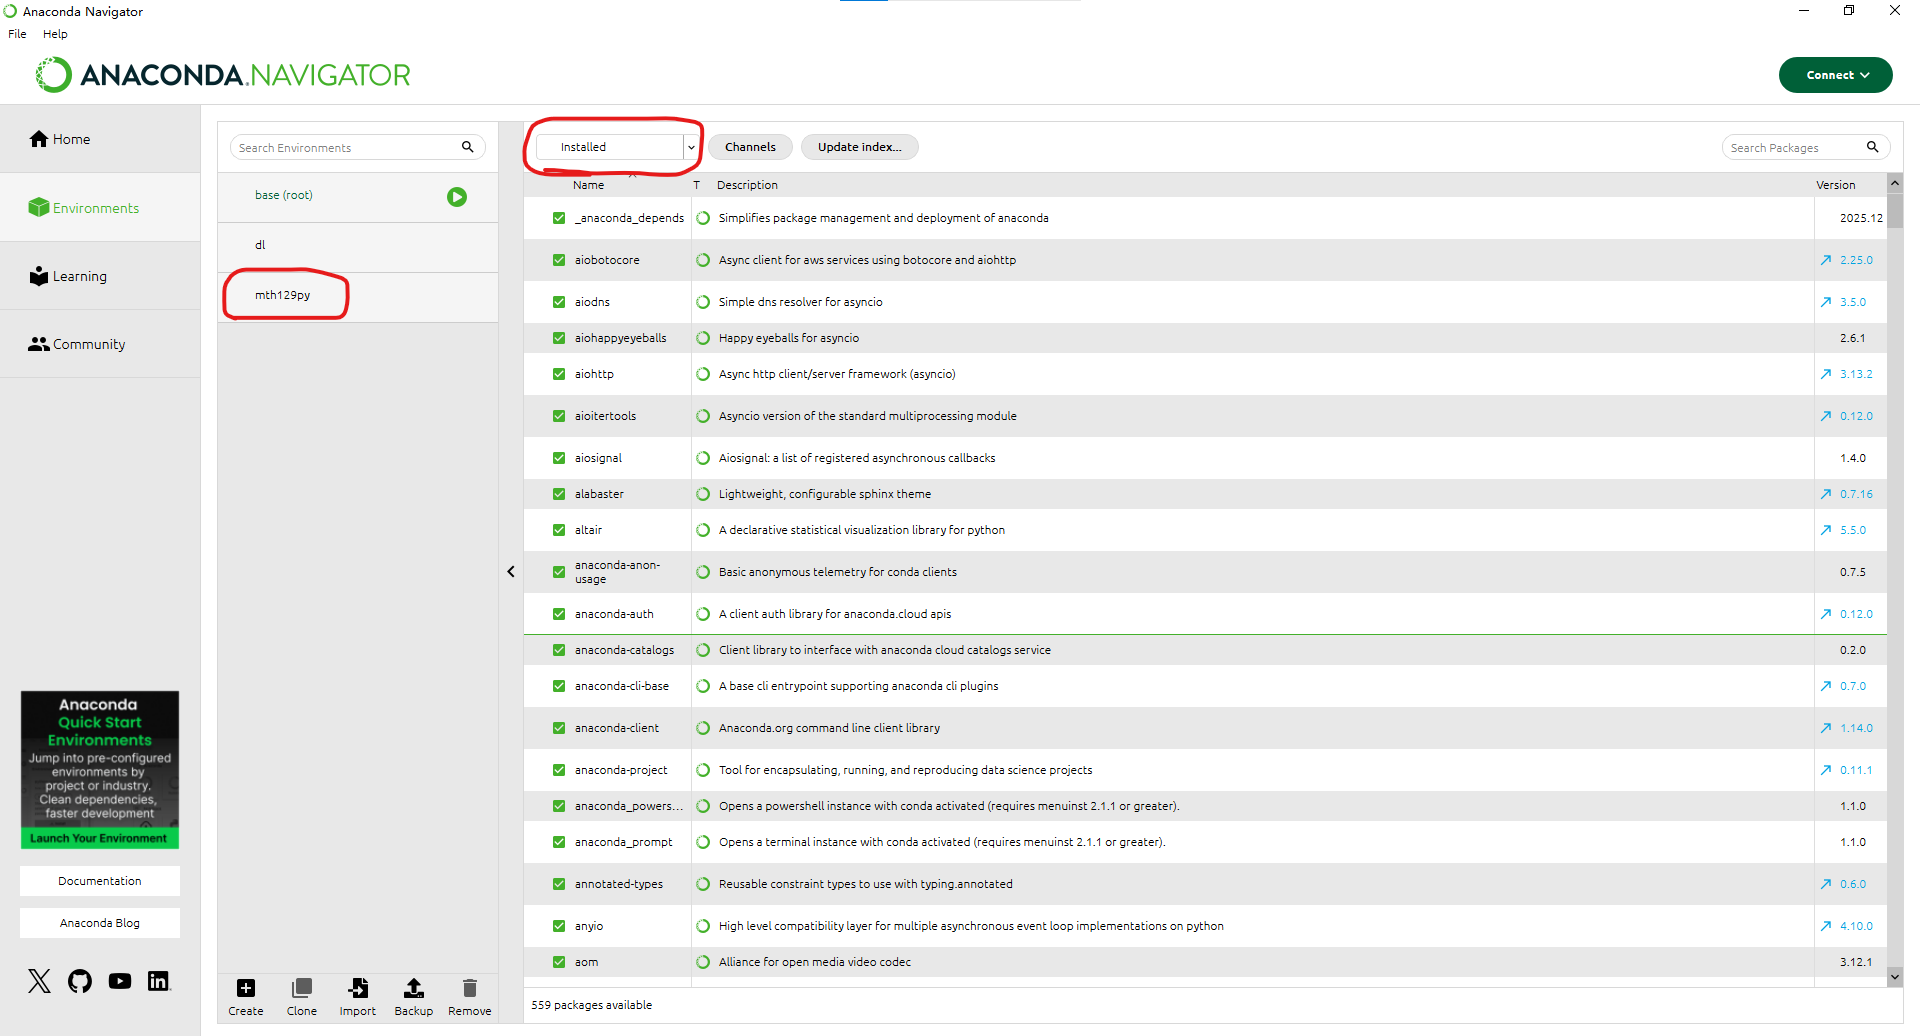

In my display I choose "ALL" to show all the packages. Then I search for "scikit-learn" in the search bar:

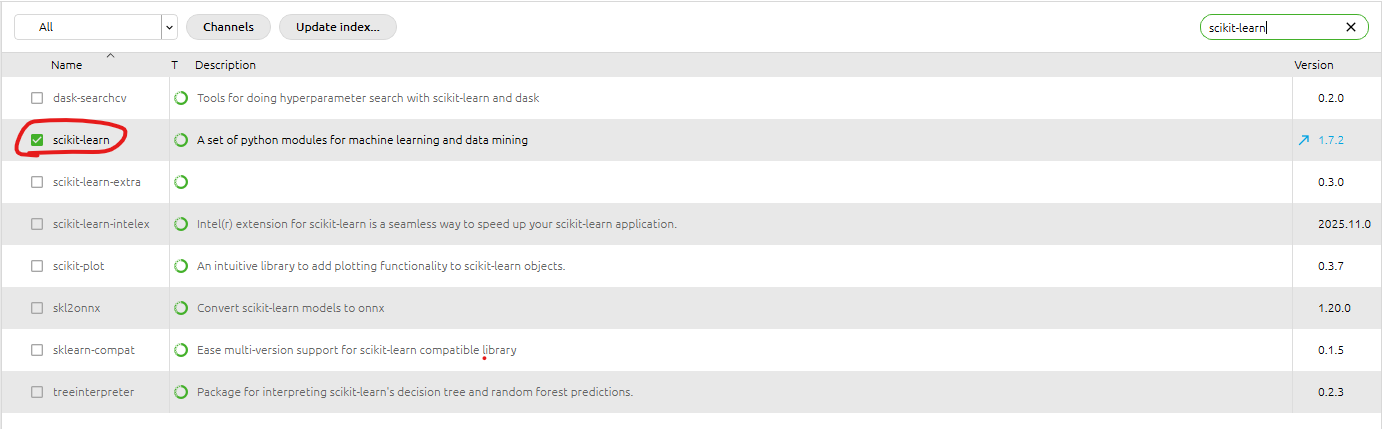

If the package is not installed, click on the package name to select it, and then click on the **Apply** button to install it. (I use another package as example)

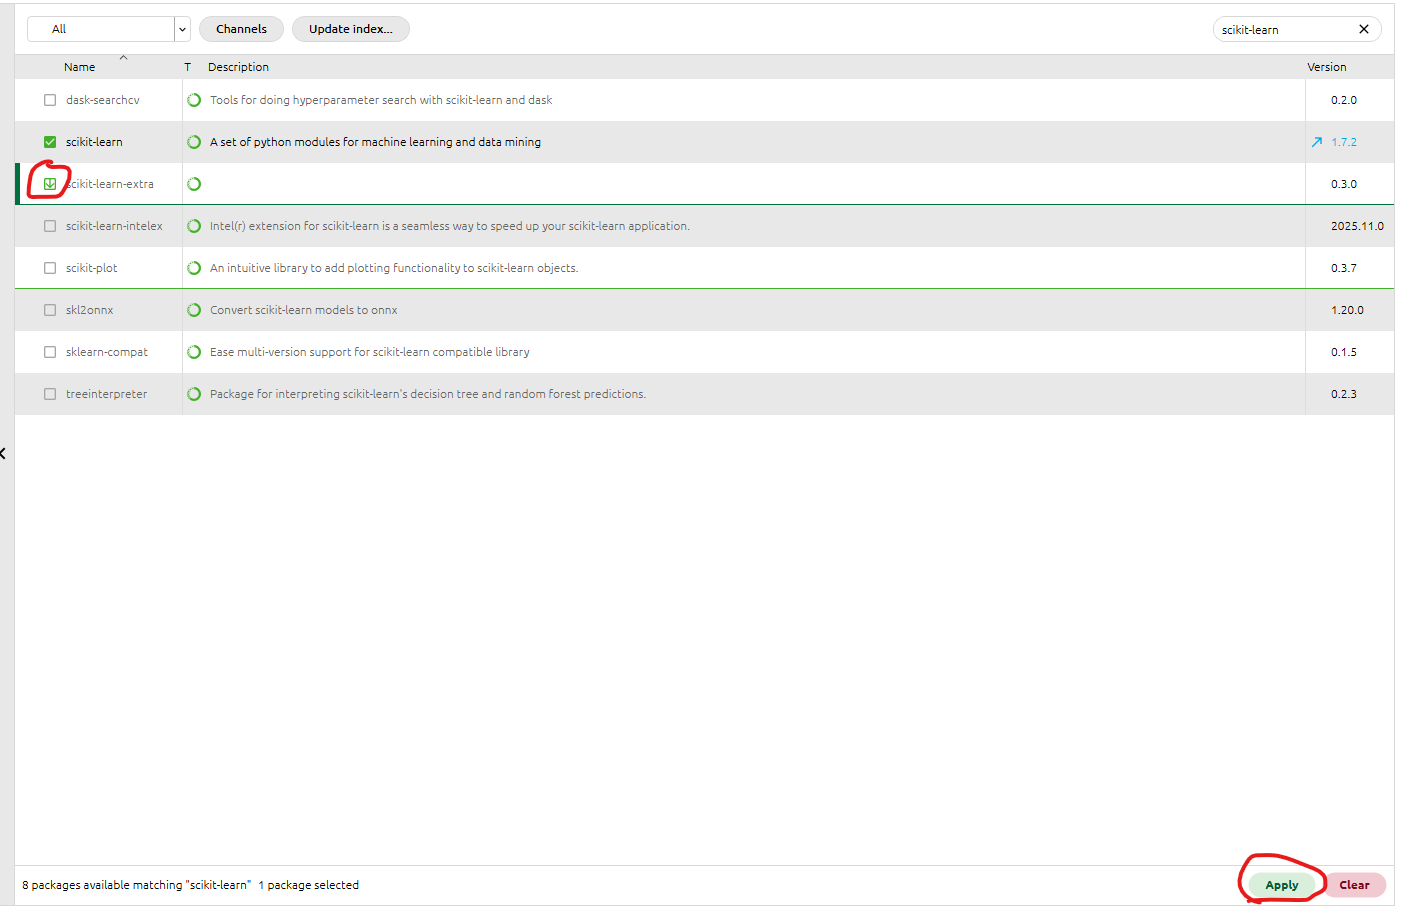

In [1]:
# --- IMPORT LIBRARIES ---
# Numerical computing and data manipulation
import numpy as np
import pandas as pd
# plotting
import matplotlib.pyplot as plt
# dataset and data splitting
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# models used in this tutorial
from sklearn.linear_model import LinearRegression, LogisticRegression, Perceptron, Ridge, Lasso
# evaluation metrics of regression and classification models
from sklearn.metrics import mean_squared_error, accuracy_score, roc_auc_score
# feature scaling, here we use standardization (z-score normalization)
from sklearn.preprocessing import StandardScaler
# ROC curve and confusion matrix plotting
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

# Data preparation and loading

Here we will split the original notebook into some cells. Each cell will focus on a specific topic.

The code `load_breast_cancer()` will load the dataset. breast_cancer is a dictionary-like object, which contains the following keys:
1. `data`: the feature matrix, which is a 2D array of shape (n_samples, n_features)
2. `target`: the target vector, which is a 1D array of shape (n_samples,)
3. `target_names`: the names of the target classes
4. `feature_names`: the names of the features
5. `DESCR`: the full description of the dataset

In [2]:
# --- LOAD AND PREPARE DATASET (Breast Cancer Wisconsin) ---
# loading the breast cancer wisconsin dataset, which is a commonly used dataset for binary classification tasks
# the dataset contains 569 samples of malignant and benign tumors, 
# with 30 features extracted from digitized images of fine needle aspirate (FNA) of breast mass
data = load_breast_cancer() 
# We use pandas DataFrame to store the features for better visualization and manipulation
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

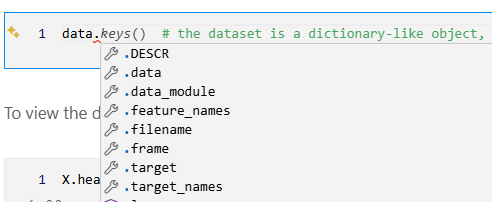

To view the details to the feature $X$, we can use the method `X.head()` to view the first 5 rows of the dataset.

In [3]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


For simplicity, we keep 4 features: mean radius, mean texture, mean perimeter, and mean area.

In [4]:
selected_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']
X = X[selected_features]

In [5]:
# fixt the random seed for reproducibility
np.random.seed(42)
# construct a regression target: mean area * 10 + noise
y_regression = X['mean area'] * 10 + np.random.normal(0, 20, len(X))

**What is random seed?**\
Random seed is a number that is used to initialize a random number generator.

**Why adding noise?**\
Adding noise to the target variable is a common practice in regression problems. It helps to simulate real-world scenarios where the target variable is affected by random factors.

Here, `np.random.normal(0, 20, len(X))` generates a random noise vector with mean 0 and standard deviation 20, which is then added to the target variable `y_regression`.

In [6]:
# view the dataset after feature selection
print("Dataset shape:", X.shape)
print("Features:", selected_features)
print("\nFirst 5 samples:")
display(X.head())

# display(y.head())
# The original code in this notebook is wrong, as it does not transform the traget to a DataFrame.
y = pd.Series(y)
display(y.head())


Dataset shape: (569, 4)
Features: ['mean radius', 'mean texture', 'mean perimeter', 'mean area']

First 5 samples:


,mean radius,mean texture,mean perimeter,mean area
0,17.99,10.38,122.80,1001.0
1,20.57,17.77,132.90,1326.0
2,19.69,21.25,130.00,1203.0
3,11.42,20.38,77.58,386.1
4,20.29,14.34,135.10,1297.0


0    0
1    0
2    0
3    0
4    0
dtype: int64

After we define the X and y, we need to split the dataset into training and testing sets. This can be achieved using the `train_test_split` function from scikit-learn. The parameters in this command are as follows:

1. **X**: The feature matrix.
2. **y**: The target vector.
3. **y_regression**: The regression target vector.
4. **test_size**: The proportion of the dataset to include in the test split. In this case, 20% of the data will be used for testing.
5. **random_state**: The seed used by the random number generator. This ensures reproducibility of the split.


In [7]:
# --- TRAIN-TEST SPLIT ---
X_train, X_test, y_train, y_test, y_train_reg, y_test_reg = train_test_split(
    X, y, y_regression, test_size=0.2, random_state=42
)

Then we do the scaling on the training set and the test set. We use `StandardScaler` to standardize the features. The mathematical formula for standardization is:
$$
x_{scaled} = \frac{x - \mu}{\sigma}
$$
where $\mu$ is the mean of the feature and $\sigma$ is the standard deviation of the feature.

In [8]:
# The scaling is only fitted on the training set to avoid data leakage from the test set into the training process
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# The test set is transformed using the scaler fitted on the training set
X_test_scaled = scaler.transform(X_test)

Then you finish the data loading and preprocessing. You can continue with the model training and evaluation.


# Regression Model and Evaluation

## Ordinary Least Squares (OLS) Regression

**What is MSE?**\
MSE is a measure of the average squared difference between the predicted values and the actual values. The mathematical formula for MSE is:

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

where:
- $n$ is the number of samples
- $y_i$ is the actual value of the $i$-th sample
- $\hat{y}_i$ is the predicted value of the $i$-th sample


1. ORDINARY LEAST SQUARES (OLS) REGRESSION

OLS Coefficients:
mean radius: -2.2760
mean texture: -0.2516
mean perimeter: 0.0209
mean area: 10.0220
Intercept: 20.4973

Test MSE: 346.11


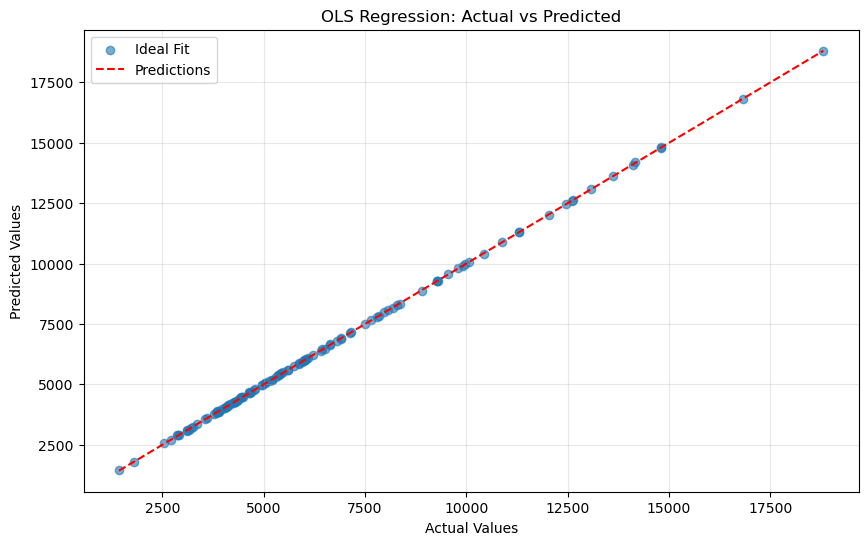

In [9]:
# ====================================================================
# 1. ORDINARY LEAST SQUARES (OLS) REGRESSION
# ====================================================================
print("\n" + "="*50)
print("1. ORDINARY LEAST SQUARES (OLS) REGRESSION")
print("="*50)
# In sklearn, the process of machine learning is typically divided into several setps:

# 1. Define the model
ols = LinearRegression()

#  2. Fit the model on the training data
ols.fit(X_train, y_train_reg)

# 3. Make predictions on the test data
ols_pred = ols.predict(X_test)
# Evaluate the model using mean squared error (MSE)
ols_mse = mean_squared_error(y_test_reg, ols_pred)

print("\nOLS Coefficients:")
# print the coefficients for each feature and the intercept
for feature, coef in zip(selected_features, ols.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {ols.intercept_:.4f}")
print(f"\nTest MSE: {ols_mse:.2f}")

# plot the actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, ols_pred, alpha=0.6)
plt.plot([min(y_test_reg), max(y_test_reg)], [min(y_test_reg), max(y_test_reg)], 'r--')
plt.title("OLS Regression: Actual vs Predicted")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend(["Ideal Fit", "Predictions"])
plt.grid(alpha=0.3)
plt.show()

using the results above, we can write the OLS regression model as:
$
\begin{equation}
y = -2.2760x_1 -0.2516x_2 + 0.0209x_3+10.0220x_4+20.4973
\end{equation}
$

## Weighted Least Squares (WLS) Regression

WLS regression is a variant of linear regression that allows for the weighting of observations based on their variance. This is useful when we have reason to believe that some observations are more important than others.


2. WEIGHTED LEAST SQUARES (WLS) REGRESSION

WLS Coefficients:
mean radius: 0.3227
mean texture: -0.2450
mean perimeter: -0.1940
mean area: 10.0102
Intercept: 11.1204

Test MSE: 347.09


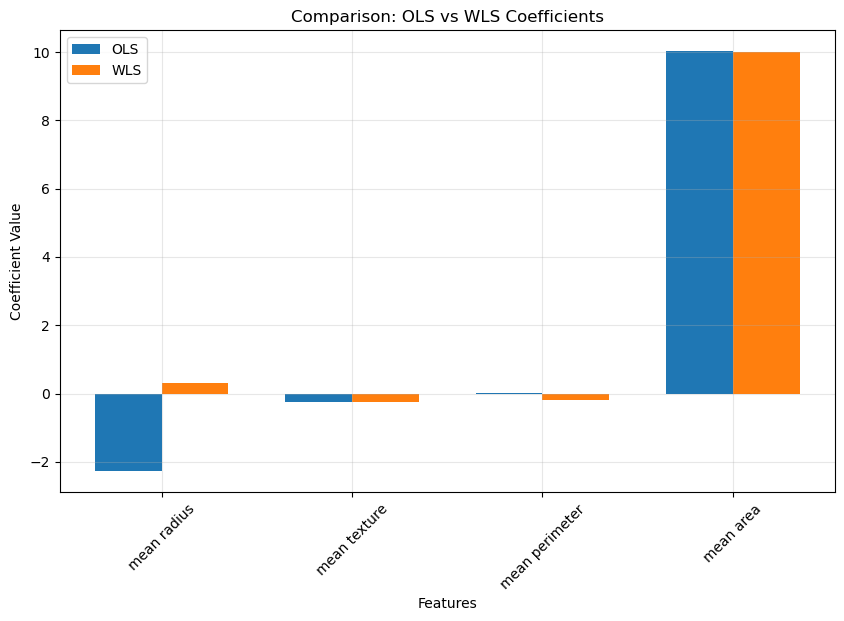

In [10]:
# ====================================================================
# 2. WEIGHTED LEAST SQUARES (WLS) REGRESSION
# ====================================================================
print("\n" + "="*50)
print("2. WEIGHTED LEAST SQUARES (WLS) REGRESSION")
print("="*50)

# Construct weights inversely proportional to the square of 'mean radius' to give 
# more importance to samples with smaller 'mean radius'
weights = 1 / (X_train['mean radius'] ** 2)

wls = LinearRegression()
wls.fit(X_train, y_train_reg, sample_weight=weights)
wls_pred = wls.predict(X_test)
wls_mse = mean_squared_error(y_test_reg, wls_pred)

print("\nWLS Coefficients:")
for feature, coef in zip(selected_features, wls.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {wls.intercept_:.4f}")
print(f"\nTest MSE: {wls_mse:.2f}")

plt.figure(figsize=(10, 6))
index = np.arange(len(selected_features))
bar_width = 0.35
plt.bar(index, ols.coef_, bar_width, label='OLS')
plt.bar(index + bar_width, wls.coef_, bar_width, label='WLS')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.title('Comparison: OLS vs WLS Coefficients')
plt.xticks(index + bar_width/2, selected_features, rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Logistic Regression

Although logistic regression is a linear model, it is used for binary classification tasks. This is because it models the probability of a binary outcome using a logistic function.

The logistic function (also known as the sigmoid function) is defined as:
$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

The shape of this function is:

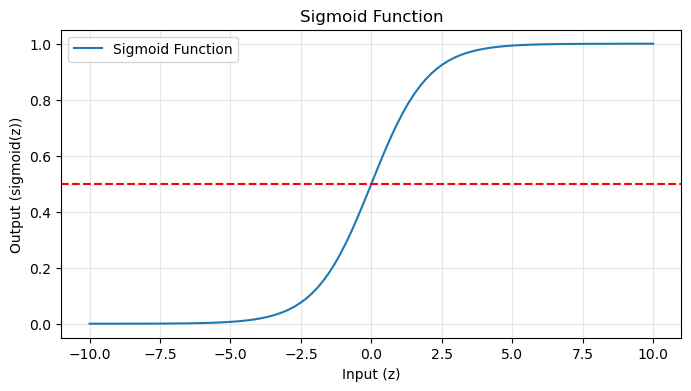

In [11]:
# sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

x = np.linspace(-10, 10, 100)
y = sigmoid(x)

plt.figure(figsize=(8,4))
plt.plot(x, y, label='Sigmoid Function')
plt.axhline(y=0.5, color='red', linestyle='--')
plt.title("Sigmoid Function")
plt.xlabel("Input (z)")
plt.ylabel("Output (sigmoid(z))")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


3. LOGISTIC REGRESSION (Classification)

Logistic Regression Coefficients:
mean radius: 30.2316
mean texture: -1.0674
mean perimeter: -26.1851
mean area: -9.6893
Intercept: -0.2147

Accuracy: 0.9386
ROC AUC: 0.9912


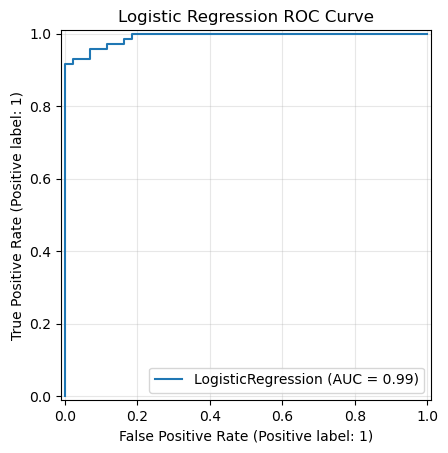

In [12]:
# ====================================================================
# 3. LOGISTIC REGRESSION (Classification)
# ====================================================================
print("\n" + "="*50)
print("3. LOGISTIC REGRESSION (Classification)")
print("="*50)

log_reg = LogisticRegression(penalty=None, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
log_reg_pred = log_reg.predict(X_test_scaled)
log_reg_prob = log_reg.predict_proba(X_test_scaled)[:, 1]
accuracy = accuracy_score(y_test, log_reg_pred)
roc_auc = roc_auc_score(y_test, log_reg_prob)

print("\nLogistic Regression Coefficients:")
for feature, coef in zip(selected_features, log_reg.coef_[0]):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {log_reg.intercept_[0]:.4f}")
print(f"\nAccuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

RocCurveDisplay.from_estimator(log_reg, X_test_scaled, y_test)
plt.title('Logistic Regression ROC Curve')
plt.grid(alpha=0.3)
plt.show()

## AUC Definition

AUC stands for **Area Under the ROC Curve**. It is the area under the ROC curve and summarizes the classifier's performance across all possible classification thresholds.

Intuitively, AUC measures how well the model can distinguish between the positive class and the negative class. In general:

- an AUC closer to **1.0** indicates better classification performance,
- an AUC around **0.5** means the classifier performs roughly like random guessing.

The mathematical definition of AUC is as follows:

$$
AUC = \int_{0}^{1} FPR(d) \, dTPR
$$

## Confusion Matrix

A confusion matrix is another useful way to evaluate a binary classifier. It compares the predicted labels with the true labels and counts how many samples fall into each case.

For a binary classification problem, the four parts are:

- **TN (True Negative)**: the true label is negative and the model predicts negative.
- **FP (False Positive)**: the true label is negative but the model predicts positive.
- **FN (False Negative)**: the true label is positive but the model predicts negative.
- **TP (True Positive)**: the true label is positive and the model predicts positive.

A better classifier usually has larger values on the main diagonal (TN and TP) and smaller values off the diagonal (FP and FN).

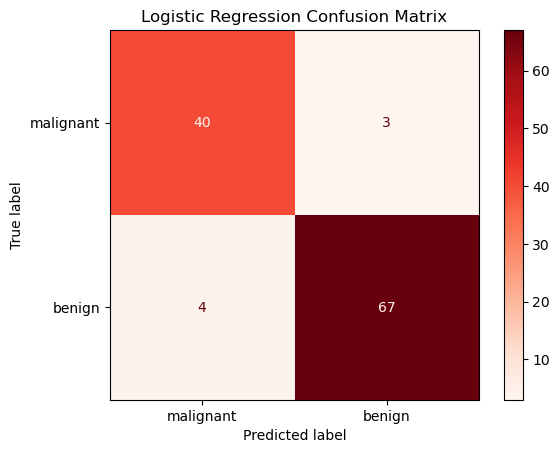

In [13]:
# --- CONFUSION MATRIX FOR LOGISTIC REGRESSION ---
ConfusionMatrixDisplay.from_predictions(
    y_test,
    log_reg_pred,
    display_labels=data.target_names,
    cmap='Reds',
    values_format='d'
)
plt.title('Logistic Regression Confusion Matrix')
plt.grid(False)
plt.show()

## Perceptron

Perceptron is a linear classifier that learns its weights by iteratively updating them based on misclassifications.


4. PERCEPTRON (Linear Classifier)

Perceptron Coefficients:
mean radius: 0.7220
mean texture: -0.0150
mean perimeter: -1.1757
mean area: -0.1103
Intercept: 0.0000

Accuracy: 0.9123


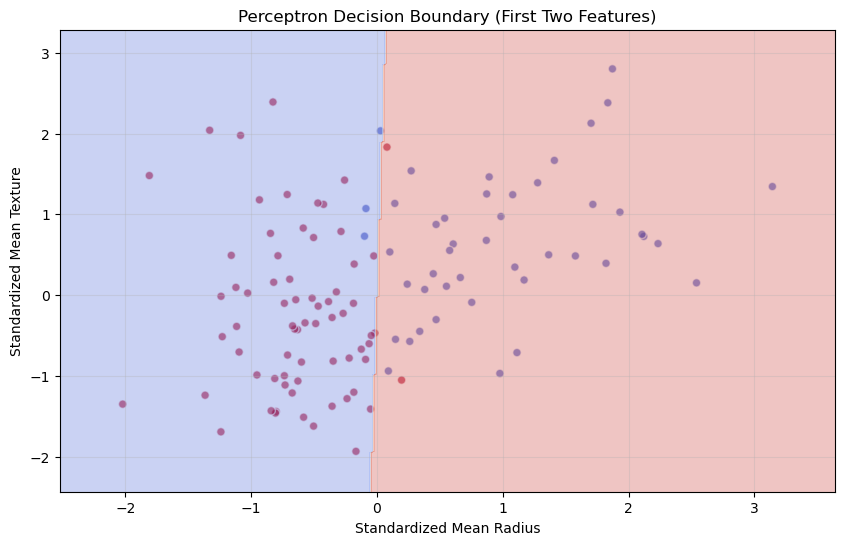

In [14]:
# ====================================================================
# 4. PERCEPTRON (Linear Classifier)
# ====================================================================
print("\n" + "="*50)
print("4. PERCEPTRON (Linear Classifier)")
print("="*50)

perceptron = Perceptron(max_iter=1000, eta0=0.1, random_state=42)
perceptron.fit(X_train_scaled, y_train)
perceptron_pred = perceptron.predict(X_test_scaled)
accuracy = accuracy_score(y_test, perceptron_pred)

print("\nPerceptron Coefficients:")
for feature, coef in zip(selected_features, perceptron.coef_[0]):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {perceptron.intercept_[0]:.4f}")
print(f"\nAccuracy: {accuracy:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=perceptron_pred, 
            cmap='coolwarm', alpha=0.6, edgecolors='w')

x_min, x_max = X_test_scaled[:, 0].min() - 0.5, X_test_scaled[:, 0].max() + 0.5
y_min, y_max = X_test_scaled[:, 1].min() - 0.5, X_test_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = perceptron.predict(np.c_[xx.ravel(), yy.ravel(),
                            np.zeros_like(xx.ravel()),
                            np.zeros_like(xx.ravel())])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.title("Perceptron Decision Boundary (First Two Features)")
plt.xlabel("Standardized Mean Radius")
plt.ylabel("Standardized Mean Texture")
plt.grid(alpha=0.3)
plt.show()

## Ridge & Lasso Regression

Ridge regression and Lasso regression are two common **regularized linear regression** methods. They start from ordinary least squares (OLS), but add a penalty term to the loss function in order to control the size of the coefficients.

For ordinary least squares, the objective function is:

$$
\min_{\beta_0,\beta} \sum_{i=1}^{n} \left(y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij}\right)^2
$$

### Ridge Regression

Ridge regression adds an **L2 penalty** (the sum of squared coefficients):

$$
\min_{\beta_0,\beta} \sum_{i=1}^{n} \left(y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij}\right)^2 + \lambda \sum_{j=1}^{p} \beta_j^2
$$

Here, $\lambda \ge 0$ is the regularization parameter. A larger $\lambda$ means a stronger penalty, so the coefficients are shrunk more strongly toward zero.

### Lasso Regression

Lasso regression adds an **L1 penalty** (the sum of absolute values of the coefficients):

$$
\min_{\beta_0,\beta} \sum_{i=1}^{n} \left(y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij}\right)^2 + \lambda \sum_{j=1}^{p} |\beta_j|
$$

Because of the L1 penalty, Lasso can push some coefficients exactly to zero. Therefore, it can also be viewed as a simple form of **feature selection**.

### Main Difference

- **Ridge** shrinks coefficients toward zero, but usually does not make them exactly zero.
- **Lasso** may shrink some coefficients all the way to zero, which removes those variables from the model.

In short, Ridge is useful when we want to keep all features but reduce overfitting, while Lasso is useful when we want both regularization and possible variable selection.


5. PENALIZED OLS (Ridge & Lasso Regression)

Ridge Coefficients:
mean radius: 143.7027
mean texture: -2.5298
mean perimeter: 111.8191
mean area: 3287.0783
Intercept: 6543.6223
Test MSE: 1612.19

Lasso Coefficients:
mean radius: -40.5566
mean texture: -1.2037
mean perimeter: 28.8859
mean area: 3557.3672
Intercept: 6543.6223
Test MSE: 350.84


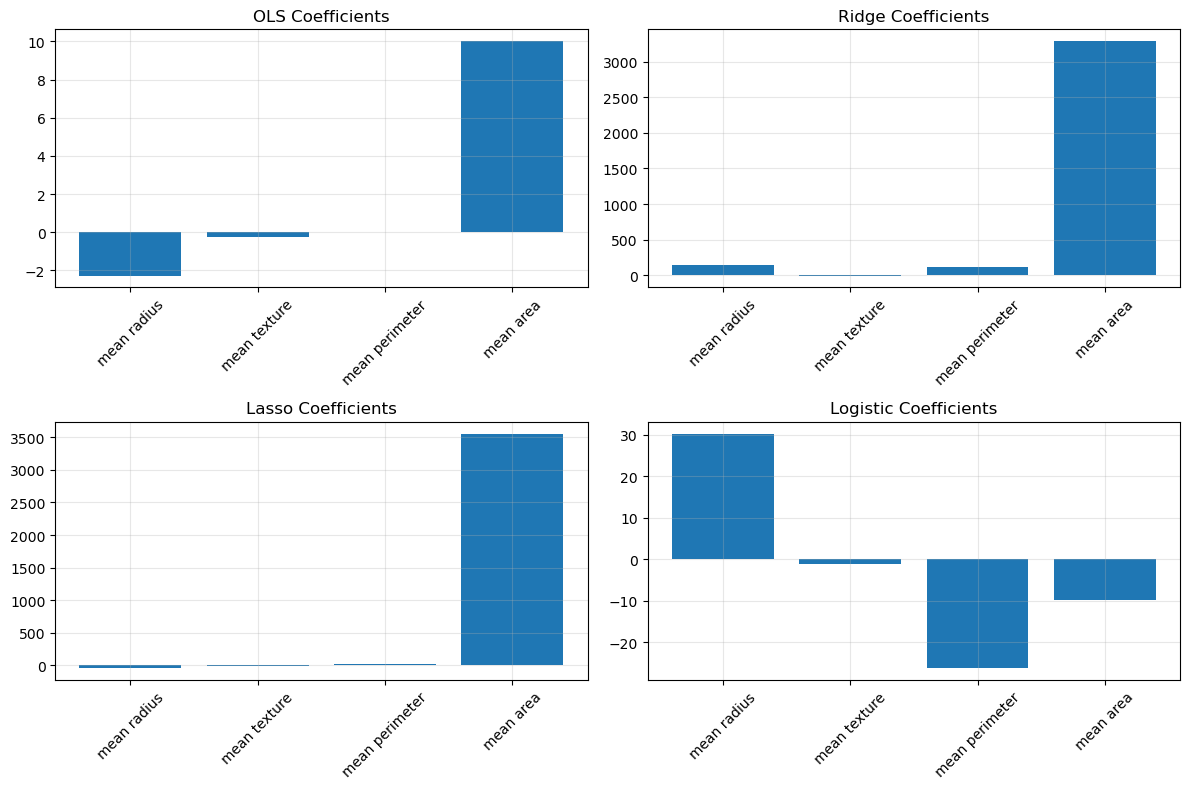

In [15]:
# ====================================================================
# 5. PENALIZED OLS (Ridge & Lasso Regression)
# ====================================================================
print("\n" + "="*50)
print("5. PENALIZED OLS (Ridge & Lasso Regression)")
print("="*50)

ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1, max_iter=10000)
ridge.fit(X_train_scaled, y_train_reg)
lasso.fit(X_train_scaled, y_train_reg)

ridge_pred = ridge.predict(X_test_scaled)
lasso_pred = lasso.predict(X_test_scaled)
ridge_mse = mean_squared_error(y_test_reg, ridge_pred)
lasso_mse = mean_squared_error(y_test_reg, lasso_pred)

print("\nRidge Coefficients:")
for feature, coef in zip(selected_features, ridge.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {ridge.intercept_:.4f}")
print(f"Test MSE: {ridge_mse:.2f}")

print("\nLasso Coefficients:")
for feature, coef in zip(selected_features, lasso.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {lasso.intercept_:.4f}")
print(f"Test MSE: {lasso_mse:.2f}")

models = [('OLS', ols.coef_), 
          ('Ridge', ridge.coef_), 
          ('Lasso', lasso.coef_),
          ('Logistic', log_reg.coef_[0])]

plt.figure(figsize=(12, 8))
for i, model in enumerate(models):
    plt.subplot(2, 2, i+1)
    plt.bar(selected_features, model[1])
    plt.title(f"{model[0]} Coefficients")
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Penalized Logistic Regression (L1 & L2 Regularization)

Penalized logistic regression extends ordinary logistic regression by adding a regularization term to the objective function. The purpose is to control model complexity, reduce overfitting, and improve generalization.

For ordinary logistic regression, if $p_i = P(y_i=1 \mid x_i)$, then

$$
p_i = \frac{1}{1 + e^{-(\beta_0 + x_i^T\beta)}}
$$

and the negative log-likelihood to be minimized can be written as:

$$
\min_{\beta_0,\beta} \; - \sum_{i=1}^{n} \left[ y_i \log(p_i) + (1-y_i)\log(1-p_i) \right]
$$

### L2-Regularized Logistic Regression

With **L2 regularization** (Ridge-type penalty), the objective becomes:

$$
\min_{\beta_0,\beta} \; - \sum_{i=1}^{n} \left[ y_i \log(p_i) + (1-y_i)\log(1-p_i) \right] + \lambda \sum_{j=1}^{p} \beta_j^2
$$

This penalty shrinks the coefficients toward zero, but usually does not make them exactly zero.

### L1-Regularized Logistic Regression

With **L1 regularization** (Lasso-type penalty), the objective becomes:

$$
\min_{\beta_0,\beta} \; - \sum_{i=1}^{n} \left[ y_i \log(p_i) + (1-y_i)\log(1-p_i) \right] + \lambda \sum_{j=1}^{p} |\beta_j|
$$

Because of the L1 penalty, some coefficients may become exactly zero. Therefore, L1-regularized logistic regression can also perform a kind of feature selection.

### Main Difference

- **L2 regularization** mainly shrinks all coefficients smoothly.
- **L1 regularization** may force some coefficients to zero.

In short, L2 regularization is often used when we want a stable model with all features retained, while L1 regularization is useful when we want both classification and possible feature selection.


6. PENALIZED LOGISTIC REGRESSION (L1 & L2 Regularization)

L1 Regularized (Lasso) Logistic Coefficients:
mean radius: 0.0000
mean texture: -0.6255
mean perimeter: -2.6445
mean area: 0.0000
Intercept: 0.6749
Accuracy: 0.9123

L2 Regularized (Ridge) Logistic Coefficients:
mean radius: -0.8186
mean texture: -0.6964
mean perimeter: -1.0921
mean area: -0.7705
Intercept: 0.6267
Accuracy: 0.9035


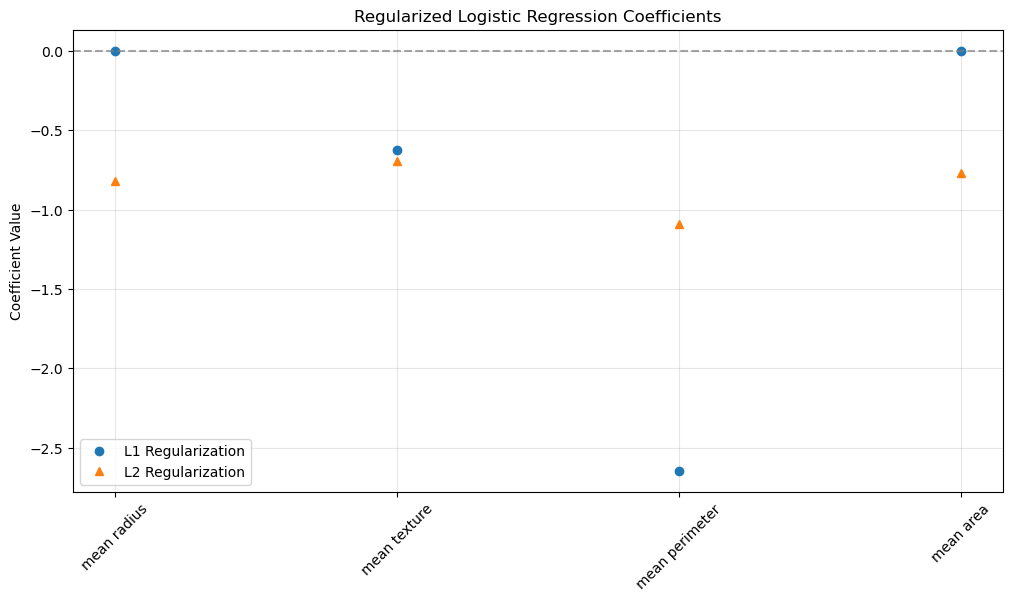

In [16]:
# ====================================================================
# 6. PENALIZED LOGISTIC REGRESSION (L1 & L2 Regularization)
# ====================================================================
print("\n" + "="*50)
print("6. PENALIZED LOGISTIC REGRESSION (L1 & L2 Regularization)")
print("="*50)

log_reg_l1 = LogisticRegression(penalty='l1', solver='saga', max_iter=1000, C=0.1)
# the parameter solver='saga' means that we use the Saga algorithm to solve the optimization problem
log_reg_l2 = LogisticRegression(penalty='l2', max_iter=1000, C=0.1)
log_reg_l1.fit(X_train_scaled, y_train)
log_reg_l2.fit(X_train_scaled, y_train)

log_reg_l1_pred = log_reg_l1.predict(X_test_scaled)
log_reg_l2_pred = log_reg_l2.predict(X_test_scaled)
accuracy_l1 = accuracy_score(y_test, log_reg_l1_pred)
accuracy_l2 = accuracy_score(y_test, log_reg_l2_pred)

print("\nL1 Regularized (Lasso) Logistic Coefficients:")
for feature, coef in zip(selected_features, log_reg_l1.coef_[0]):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {log_reg_l1.intercept_[0]:.4f}")
print(f"Accuracy: {accuracy_l1:.4f}")

print("\nL2 Regularized (Ridge) Logistic Coefficients:")
for feature, coef in zip(selected_features, log_reg_l2.coef_[0]):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {log_reg_l2.intercept_[0]:.4f}")
print(f"Accuracy: {accuracy_l2:.4f}")

plt.figure(figsize=(12, 6))
plt.plot(log_reg_l1.coef_[0], 'o', label='L1 Regularization')
plt.plot(log_reg_l2.coef_[0], '^', label='L2 Regularization')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.7)
plt.xticks(range(len(selected_features)), selected_features, rotation=45)
plt.title("Regularized Logistic Regression Coefficients")
plt.ylabel("Coefficient Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()